## Employee Analysis
### Exploratory Data Analysis

In this project is set to analyze real survey data from Stack Overflow. The focus is on exploring developers’ experience, compensation, and other factors using pandas and data visualization tools.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('developer_dataset_cleaned.csv')

print(df.columns)

Index(['RespondentID', 'Year', 'Country', 'Employment', 'UndergradMajor',
       'DevType', 'LanguageWorkedWith', 'LanguageDesireNextYear',
       'DatabaseWorkedWith', 'DatabaseDesireNextYear', 'PlatformWorkedWith',
       'PlatformDesireNextYear', 'Hobbyist', 'OrgSize', 'YearsCodePro',
       'JobSeek', 'ConvertedComp', 'WorkWeekHrs'],
      dtype='object')


In [3]:
df.count()

RespondentID              99975
Year                      99975
Country                   99975
Employment                99975
UndergradMajor            99973
DevType                   99975
LanguageWorkedWith        93514
LanguageDesireNextYear    88101
DatabaseWorkedWith        80241
DatabaseDesireNextYear    69346
PlatformWorkedWith        84252
PlatformDesireNextYear    78553
Hobbyist                  59930
OrgSize                   53849
YearsCodePro              86552
JobSeek                   56951
ConvertedComp             83316
WorkWeekHrs               50292
dtype: int64

In [4]:
df.describe()

,RespondentID,Year,YearsCodePro,ConvertedComp,WorkWeekHrs
count,99975.000000,99975.000000,86552.000000,8.331600e+04,50292.000000
mean,19204.655684,2018.816194,9.503501,1.291564e+05,41.030652
std,11845.056547,0.763882,7.555109,2.550390e+05,13.783042
min,1.000000,2018.000000,0.000000,0.000000e+00,1.000000
25%,9109.000000,2018.000000,4.000000,4.700000e+04,40.000000
50%,18354.000000,2019.000000,8.000000,7.900000e+04,40.000000
75%,28568.500000,2019.000000,14.000000,1.200000e+05,42.000000
max,42847.000000,2020.000000,50.000000,2.000000e+06,475.000000


### Removing Highly Missing Data

In [5]:
# Printing out missing percentage of each column

# We can use the ID as our total row count, since every respondent gets a unique ID
maxRows = df['RespondentID'].count()

print('% Missing Data:')
print((1 - df.count() / maxRows) * 100)

% Missing Data:
RespondentID               0.000000
Year                       0.000000
Country                    0.000000
Employment                 0.000000
UndergradMajor             0.002001
DevType                    0.000000
LanguageWorkedWith         6.462616
LanguageDesireNextYear    11.876969
DatabaseWorkedWith        19.738935
DatabaseDesireNextYear    30.636659
PlatformWorkedWith        15.726932
PlatformDesireNextYear    21.427357
Hobbyist                  40.055014
OrgSize                   46.137534
YearsCodePro              13.426357
JobSeek                   43.034759
ConvertedComp             16.663166
WorkWeekHrs               49.695424
dtype: float64


In [6]:
df.drop(['NEWJobHunt','NEWJobHuntResearch','NEWLearn'],
    axis=1,
    inplace=True,
        errors='ignore')

print(df.columns.tolist())

['RespondentID', 'Year', 'Country', 'Employment', 'UndergradMajor', 'DevType', 'LanguageWorkedWith', 'LanguageDesireNextYear', 'DatabaseWorkedWith', 'DatabaseDesireNextYear', 'PlatformWorkedWith', 'PlatformDesireNextYear', 'Hobbyist', 'OrgSize', 'YearsCodePro', 'JobSeek', 'ConvertedComp', 'WorkWeekHrs']


### Developer Analysis by Country

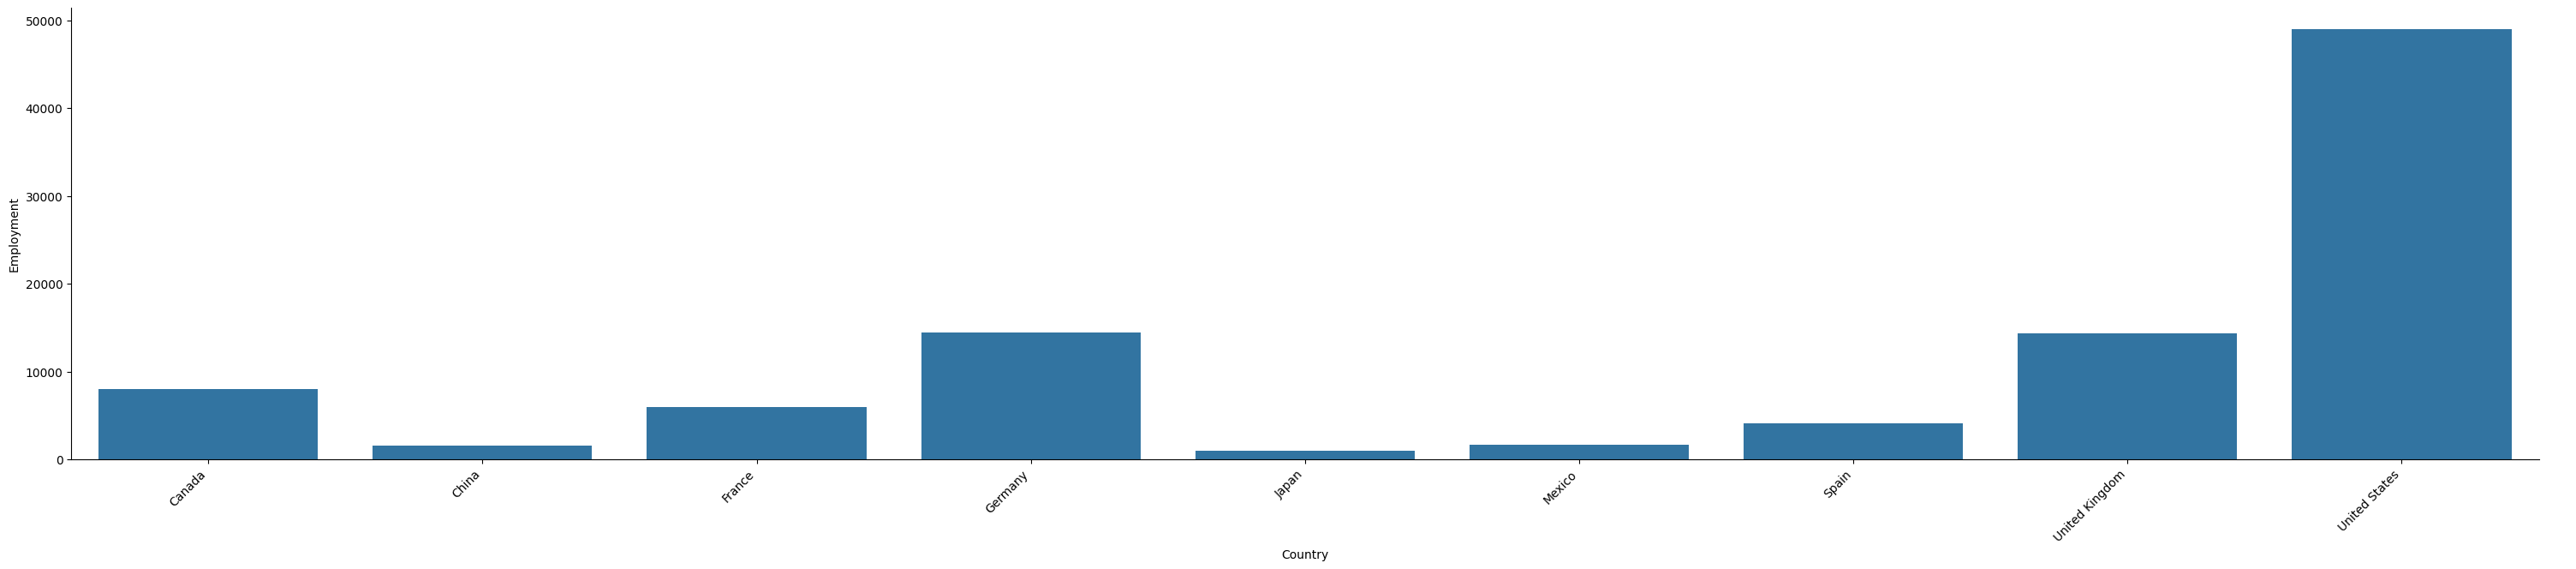

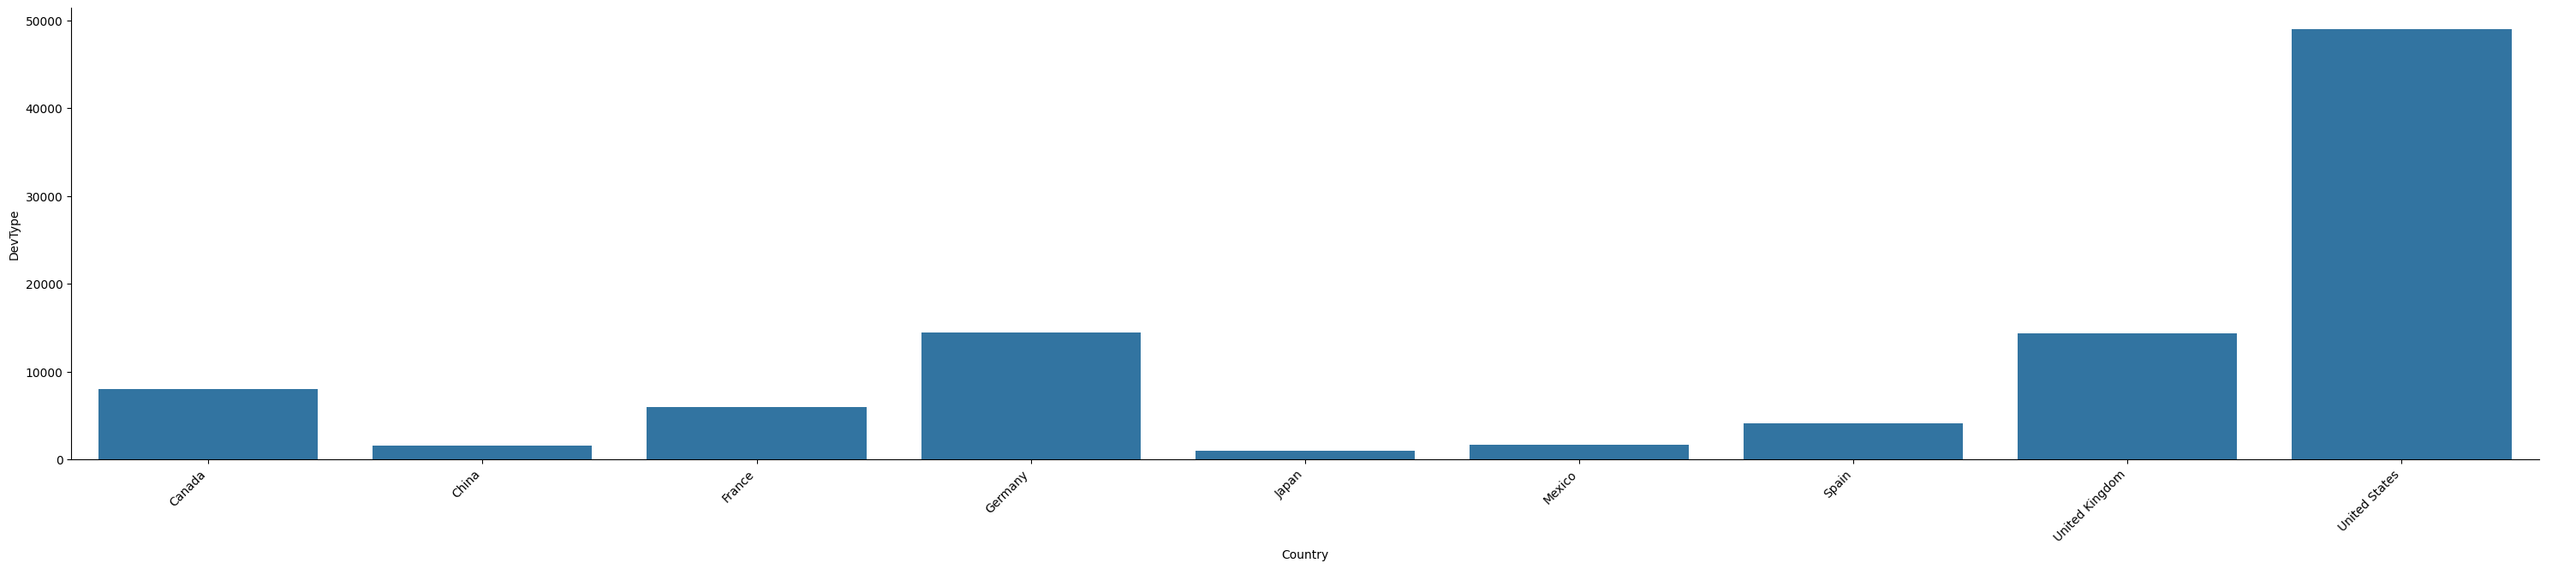

(9, 3)
   Country  Employment  DevType
0   Canada        7993     7993
1    China        1567     1567
2   France        5985     5985
3  Germany       14408    14408
4    Japan         938      938
9


In [7]:
missingData = df.groupby('Country')[['Employment','DevType']].count().reset_index()

A=sns.catplot(
    data=missingData, kind="bar",
    x="Country", y="Employment",
    height = 6, aspect = 5)
A.set_xticklabels(rotation=45, ha="right")

B=sns.catplot(
    data=missingData, kind="bar",
    x="Country", y="DevType",
    height = 6, aspect = 5)
B.set_xticklabels(rotation=45, ha="right")


plt.show()
print(missingData.shape)
print(missingData.head())
print(len(missingData))

In [10]:
df.dropna(subset = ['Employment','DevType'],
    inplace = True,
    how = 'any')

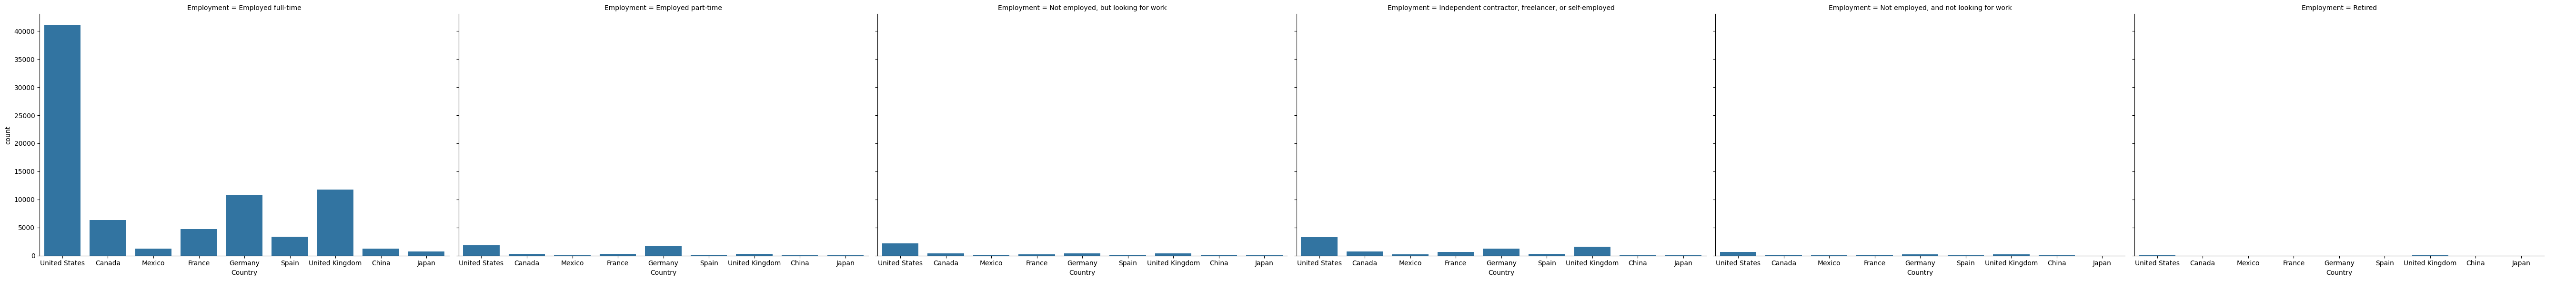

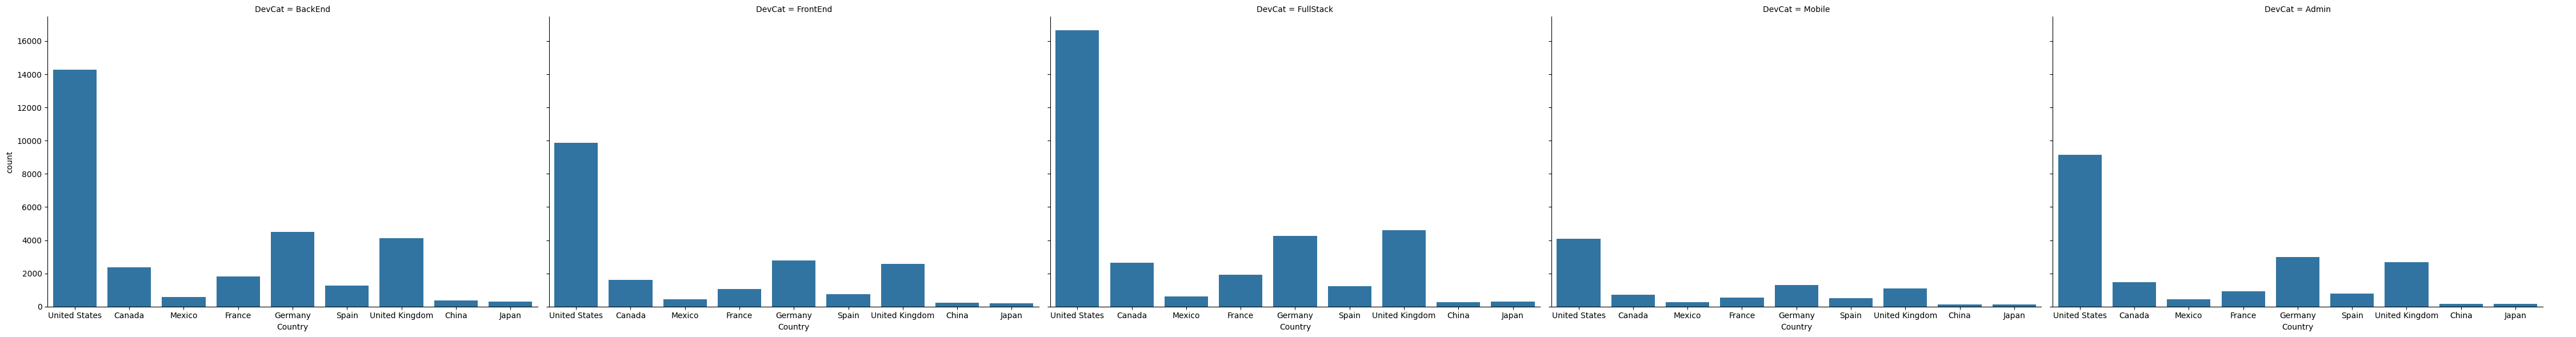

In [8]:
# Visualizing employmnet status by country
# Extracting developer roles from survey data and visualizing them
empfig = sns.catplot(x="Country", col="Employment",
                data=df, kind="count",
                height=6, aspect=1.5);


# We will focus on a few of the key developer types outlined in the Stack Overflow survey
devdf = df[['Country', 'DevType']].copy()
devdf.loc[devdf['DevType'].str.contains('back-end'), 'BackEnd'] = True
devdf.loc[devdf['DevType'].str.contains('front-end'), 'FrontEnd'] = True
devdf.loc[devdf['DevType'].str.contains('full-stack'), 'FullStack'] = True
devdf.loc[devdf['DevType'].str.contains('mobile'), 'Mobile'] = True
devdf.loc[devdf['DevType'].str.contains('administrator'), 'Admin'] = True

devdf = devdf.melt(id_vars=['Country'], 
    value_vars=['BackEnd','FrontEnd','FullStack','Mobile','Admin'], 
    var_name='DevCat',
    value_name='DevFlag')

devdf.dropna(how='any', inplace=True)

devFig = sns.catplot(x="Country", col="DevCat",
                data=devdf, kind="count",
                height=6, aspect=1.5);

### Developer Undergrad Majors

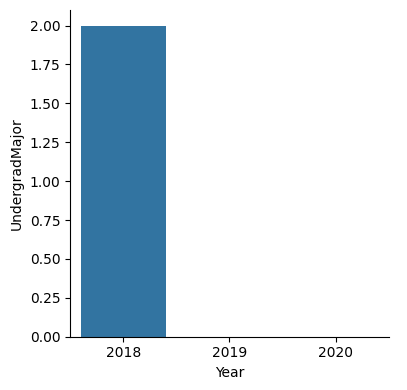

In [9]:
missingUndergrad = df['UndergradMajor'].isnull().groupby(df['Year']).sum().reset_index()

sns.catplot(x="Year", y="UndergradMajor",
                data=missingUndergrad, kind="bar",
                height=4, aspect=1);

In [10]:
# Sorting by ID and Year so that each person's data is carried backwards correctly
df = df.sort_values(['RespondentID','Year'])

df['UndergradMajor'] = (df.groupby('RespondentID')['UndergradMajor'].bfill())

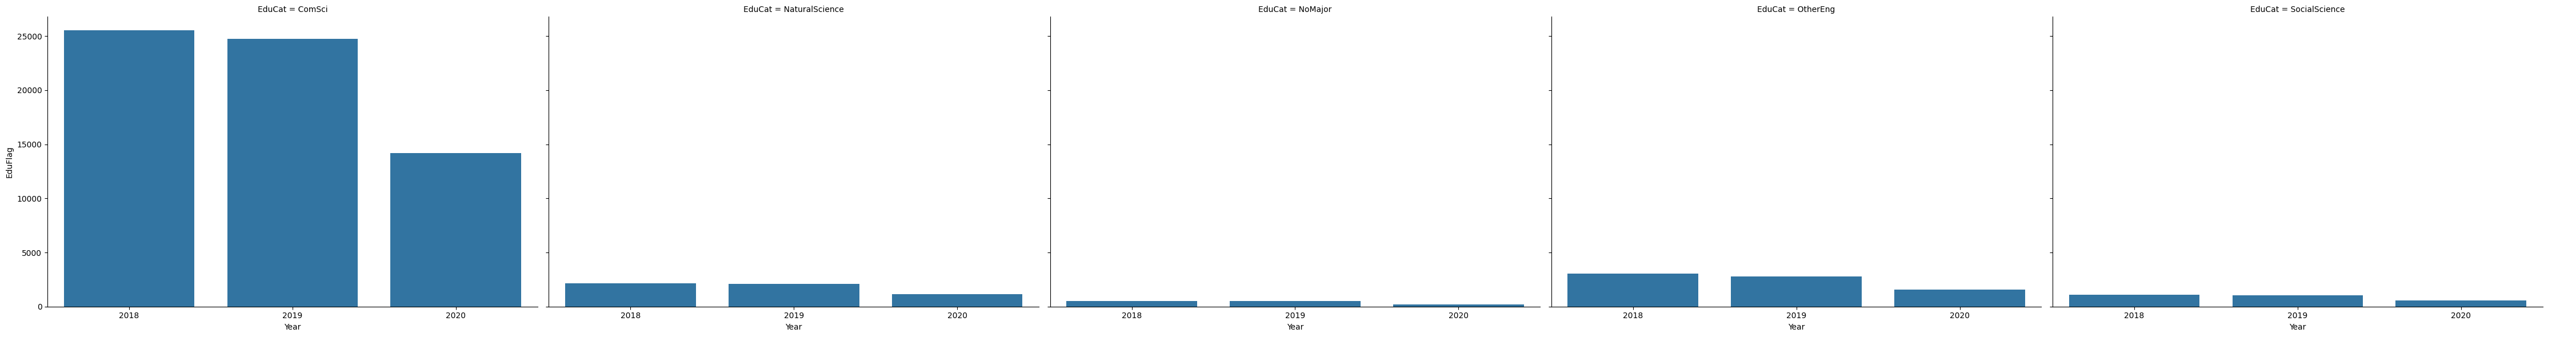

In [11]:
# We will focus on a few of the key major groups outlined in the Stack Overflow survey
# It answers the question, what educational backgrounds do developers come from, and how has that changed over the years?

majors = ['social science','natural science','computer science','development','another engineering','never declared']

edudf = df[['Year','UndergradMajor']].copy()
edudf.dropna(how='any', inplace=True)
edudf.loc[edudf['UndergradMajor'].str.contains('(?i)social science'), 'SocialScience'] = True
edudf.loc[edudf['UndergradMajor'].str.contains('(?i)natural science'), 'NaturalScience'] = True
edudf.loc[edudf['UndergradMajor'].str.contains('(?i)computer science'), 'ComSci'] = True
edudf.loc[edudf['UndergradMajor'].str.contains('(?i)development'), 'ComSci'] = True
edudf.loc[edudf['UndergradMajor'].str.contains('(?i)another engineering'), 'OtherEng'] = True
edudf.loc[edudf['UndergradMajor'].str.contains('(?i)never declared'), 'NoMajor'] = True

edudf = edudf.melt(id_vars=['Year'], 
    value_vars=['SocialScience','NaturalScience','ComSci','OtherEng','NoMajor'], 
    var_name='EduCat',
    value_name='EduFlag')

edudf.dropna(how='any', inplace=True)
edudf = edudf.groupby(['Year','EduCat']).count().reset_index()

eduFig = sns.catplot(x="Year", y='EduFlag', col="EduCat",
                data=edudf, kind="bar",
                height=6, aspect=1.5);

### Relationship between Years Experience and Compensation

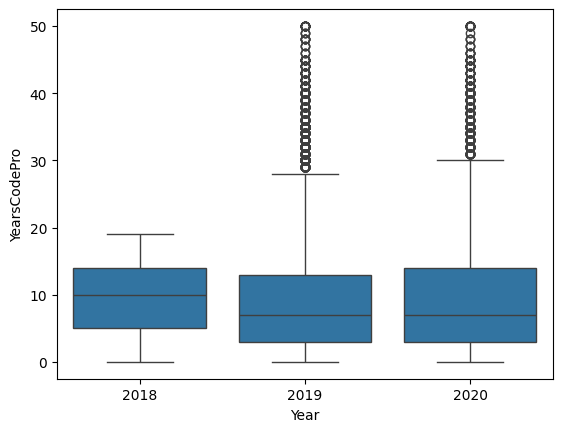

In [12]:
compFields = df[['Year','YearsCodePro','ConvertedComp']]

D = sns.boxplot(x="Year", y="YearsCodePro",
            data=compFields)

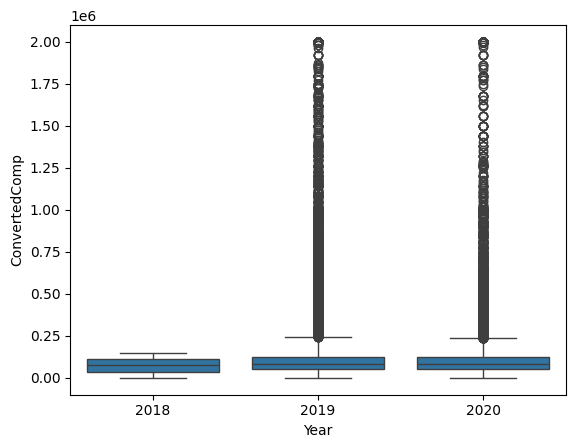

In [13]:
E = sns.boxplot(x="Year", y="ConvertedComp",
            data=compFields)

In [14]:
# Estimating missing values 
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
!pip install scikit-learn
import sys
!{sys.executable} -m pip install scikit-learn

imputedf = df[['YearsCodePro','ConvertedComp']]

traindf, testdf = train_test_split(imputedf, train_size=0.1)

# Create the IterativeImputer model to predict missing values
imp = IterativeImputer(max_iter=20, random_state=0)

# Fit the model to the the test dataset
imp.fit(imputedf)

# Transform the model on the entire dataset
compdf = pd.DataFrame(np.round(imp.transform(imputedf),0), columns=['YearsCodePro','ConvertedComp'])

In [15]:
compdf.isnull().sum()

YearsCodePro     0
ConvertedComp    0
dtype: int64

<Axes: xlabel='CodeYearBins', ylabel='ConvertedComp'>

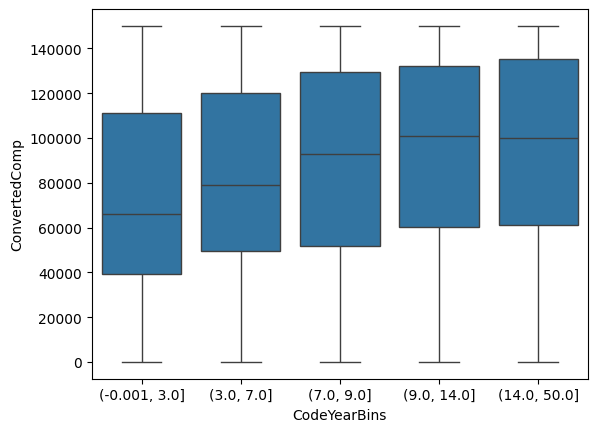

In [16]:
# Reducing the range for viewing simplicity
# This code prepares salary data for visualization and then creates a boxplot showing: How salary changes with years of professional coding experience.

compPlotdf = compdf.loc[compdf['ConvertedComp'] <= 150000].copy()
compPlotdf['CodeYearBins'] = pd.qcut(compPlotdf['YearsCodePro'], q=5)

sns.boxplot(x="CodeYearBins", y="ConvertedComp",
            data=compPlotdf)

In [17]:
df.to_csv('developer_dataset_cleaned.csv', index=False, header=True)